Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3084 - Data Science - sección 40

Cristian Túnchez (231359)  
Nadissa Vela (23764)

# Laboratorio 6: Análisis de Redes Sociales en YouTube

## Notebook 3 - Redes, proyecciones, topología, comunidades, nodos centrales y puente

Este notebook resuelve los **Ejercicios 4, 5, 6, 7 y 8** del laboratorio.

Hasta ahora los datos se han descrito como tablas. Aquí se convierten en una **red**; los autores y los videos pasan a ser nodos, y cada comentario se convierte en una conexión entre ellos. Con esa representación se pueden responder preguntas que una tabla no permite, como qué tan fragmentada está la participación o qué contenidos comparten audiencia.

**Preparación del entorno**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src.utils import DATA_PROCESSED, cargar, set_estilo

set_estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

cv = cargar("comentarios_videos")
print("networkx:", nx.__version__)
print("comentarios con su video ->", cv.shape)

networkx: 3.6.1
comentarios con su video -> (406, 44)


## Ejercicio 4. Construcción de la red bipartita autor–video

### 4.1 y 4.2 Nodos, aristas y pesos

Una red **bipartita** tiene dos tipos de nodo y las aristas solo pueden ir de un tipo al otro (en este caso, de un **autor** a un **video**). Nunca hay una arista autor–autor ni video–video, porque los datos no registran ninguna relación directa entre autores.

La red es **no dirigida**, es decir, comentar no tiene un sentido de ida y vuelta como sí lo tiene seguir a alguien. El **peso** de la arista es el número de comentarios que ese autor publicó en ese video.

In [2]:
# Una fila por par (autor, video); el tamaño del grupo es el peso de la arista
aristas = (
    cv.groupby(["author_channel_id", "video_id"])
    .agg(peso=("comment_id", "size"), likes_sumados=("like_count", "sum"))
    .reset_index()
)

print("Comentarios totales:      ", len(cv))
print("Aristas (pares únicos):   ", len(aristas))
print("Suma de los pesos:        ", int(aristas["peso"].sum()), "(debe igualar los comentarios)")
print("\nDistribución de los pesos:")
print(aristas["peso"].value_counts().sort_index().rename_axis("peso").to_frame("aristas").to_string())

Comentarios totales:       406
Aristas (pares únicos):    343
Suma de los pesos:         406 (debe igualar los comentarios)

Distribución de los pesos:
      aristas
peso         
1         303
2          28
3           7
4           1
5           2
6           2


In [3]:
autores = sorted(cv["author_channel_id"].unique())
videos = sorted(cv["video_id"].unique())

B = nx.Graph()
B.add_nodes_from(autores, bipartite=0, tipo="autor")
B.add_nodes_from(videos, bipartite=1, tipo="video")
B.add_weighted_edges_from(aristas[["author_channel_id", "video_id", "peso"]].itertuples(index=False, name=None))

print("RED BIPARTITA AUTOR-VIDEO")
print("  nodos:", B.number_of_nodes(), f"({len(autores)} autores + {len(videos)} videos)")
print("  aristas:", B.number_of_edges())
print("  ¿es realmente bipartita?", nx.is_bipartite(B))
print("  ¿es conexa?", nx.is_connected(B))
print("  ¿hay aristas entre nodos del mismo tipo?",
      any(B.nodes[u]["tipo"] == B.nodes[v]["tipo"] for u, v in B.edges()))

RED BIPARTITA AUTOR-VIDEO
  nodos: 351 (332 autores + 19 videos)
  aristas: 343
  ¿es realmente bipartita? True
  ¿es conexa? False
  ¿hay aristas entre nodos del mismo tipo? False


### 4.3 Tabla de nodos y tabla de aristas

In [4]:
# Atributos de los autores
attr_autores = cv.groupby("author_channel_id").agg(
    etiqueta=("author_handle", "first"),
    n_comentarios=("comment_id", "size"),
    n_videos=("video_id", "nunique"),
    n_canales=("channel_id", "nunique"),
    likes_totales=("like_count", "sum"),
    respuestas_recibidas=("reply_count", "sum"),
).reset_index().rename(columns={"author_channel_id": "node_id"})
attr_autores["tipo"] = "autor"

# Atributos de los videos
attr_videos = cv.groupby("video_id").agg(
    etiqueta=("title", "first"),
    canal=("channel_name", "first"),
    channel_id=("channel_id", "first"),
    categoria=("category", "first"),
    view_count=("view_count", "first"),
    n_comentarios=("comment_id", "size"),
    n_autores=("author_channel_id", "nunique"),
    likes_totales=("like_count", "sum"),
).reset_index().rename(columns={"video_id": "node_id"})
attr_videos["tipo"] = "video"

nodos = pd.concat([attr_autores, attr_videos], ignore_index=True)
nodos["grado"] = nodos["node_id"].map(dict(B.degree()))
nodos["grado_ponderado"] = nodos["node_id"].map(dict(B.degree(weight="weight")))

columnas = ["node_id", "tipo", "etiqueta", "grado", "grado_ponderado", "n_comentarios",
            "n_videos", "n_autores", "n_canales", "likes_totales", "respuestas_recibidas",
            "canal", "channel_id", "categoria", "view_count"]
nodos = nodos[columnas]

# Los atributos exclusivos de un tipo de nodo quedan vacíos en el otro; se usa el entero
# nullable de pandas para que no se conviertan en decimales
for col in ["n_videos", "n_autores", "n_canales", "respuestas_recibidas", "view_count"]:
    nodos[col] = nodos[col].astype("Int64")

print("TABLA DE NODOS:", nodos.shape)
print(nodos["tipo"].value_counts().to_string())
print("\nLos 19 nodos de tipo video:")
nodos[nodos["tipo"] == "video"].sort_values("grado", ascending=False)[
    ["node_id", "etiqueta", "grado", "grado_ponderado", "canal", "categoria", "view_count"]
].head(19)

TABLA DE NODOS: (351, 15)
tipo
autor    332
video     19

Los 19 nodos de tipo video:


,node_id,etiqueta,grado,grado_ponderado,canal,categoria,view_count
346,n8iP75gIpmw,Qué rico come tu diputado,128,161,Quorum,News & Politics,11775
344,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,49,50,Quorum,News & Politics,10156
334,6W4u8sGEnGM,Inician los trabajos de recuperación del Puent...,32,45,Gobierno de la República de Guatemala,Entertainment,11670
345,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,25,25,Municipalidad de Guatemala,News & Politics,304089
337,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemal...,19,25,Gobierno de la República de Guatemala,Entertainment,3628
336,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemal...,18,25,Noticias Telemundo,News & Politics,14200
349,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,16,16,Quorum,News & Politics,1954
332,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,13,14,Noti7,News & Politics,6692
347,ndAZjHqzzT8,Internet: escoger el menos malo,10,12,Quorum,News & Politics,717
343,is3Mk5oC19g,Capturan a ladrón que había quedado grabado mi...,7,7,TN23 Guatemala,News & Politics,4616


In [5]:
print("Los 10 nodos de tipo autor con mayor grado (autores que participaron en más videos):")
nodos[nodos["tipo"] == "autor"].sort_values(["grado", "grado_ponderado"], ascending=False)[
    ["node_id", "etiqueta", "grado", "grado_ponderado", "n_videos", "n_canales", "likes_totales"]
].head(10)

Los 10 nodos de tipo autor con mayor grado (autores que participaron en más videos):


,node_id,etiqueta,grado,grado_ponderado,n_videos,n_canales,likes_totales
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,3,4,3,1,0
276,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3,3,1,4
98,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,2,3,2,2,14
325,UCylqlpsh8ENNM1LqgQ1KbxA,@jel.awesh.m,2,3,2,1,1
207,UCbrtvygfRT6QXqWDNrOf-cA,@alejandro00710,2,2,2,1,0
211,UCdFlugHJJa4l3YqWuNRmvXw,@marcoscarillo-b1r,2,2,2,2,0
250,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,2,2,0
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,2,2,0
330,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2,2,1,0
241,UCi2KiZq63sRq8Mfbcp-MelQ,@eugeneramirez4405,1,6,1,1,1


In [6]:
tabla_aristas = aristas.rename(columns={"author_channel_id": "autor", "video_id": "video"})
tabla_aristas = tabla_aristas.merge(
    attr_videos[["node_id", "canal"]].rename(columns={"node_id": "video", "canal": "canal_del_video"}),
    on="video", how="left",
)[["autor", "video", "peso", "likes_sumados", "canal_del_video"]]

print("TABLA DE ARISTAS:", tabla_aristas.shape)
tabla_aristas.sort_values("peso", ascending=False).head(10)

TABLA DE ARISTAS: (343, 5)


,autor,video,peso,likes_sumados,canal_del_video
244,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,6,1,Noticias Telemundo
331,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,6,14,Gobierno de la República de Guatemala
33,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,5,6,Quorum
165,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,5,17,Gobierno de la República de Guatemala
57,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,4,0,Quorum
46,UC72gBAtyb_VXQlYDcFrh6oQ,n8iP75gIpmw,3,19,Quorum
25,UC3XTwHxygNCgjndsg-UiCQA,n8iP75gIpmw,3,2,Quorum
226,UCg3eIfd7BrsLEqS0BLkftHA,PjmxCj-a9Hg,3,0,Gobierno de la República de Guatemala
120,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,3,3,Gobierno de la República de Guatemala
240,UChs3tU2BcKOT0CezykvAsGw,n8iP75gIpmw,3,4,Quorum


In [7]:
nodos.to_csv(DATA_PROCESSED / "nodos_bipartita.csv", index=False)
tabla_aristas.to_csv(DATA_PROCESSED / "aristas_bipartita.csv", index=False)
print("guardado -> nodos_bipartita.csv  ", nodos.shape)
print("guardado -> aristas_bipartita.csv", tabla_aristas.shape)

guardado -> nodos_bipartita.csv   (351, 15)
guardado -> aristas_bipartita.csv (343, 5)


### 4.4 Visualización de la red completa

Se dibuja la red **entera**, sin eliminar ningún nodo ni arista. Los 19 videos se rotulan; los 332 autores no se rotulan por legibilidad, pero sí aparecen todos en el dibujo.

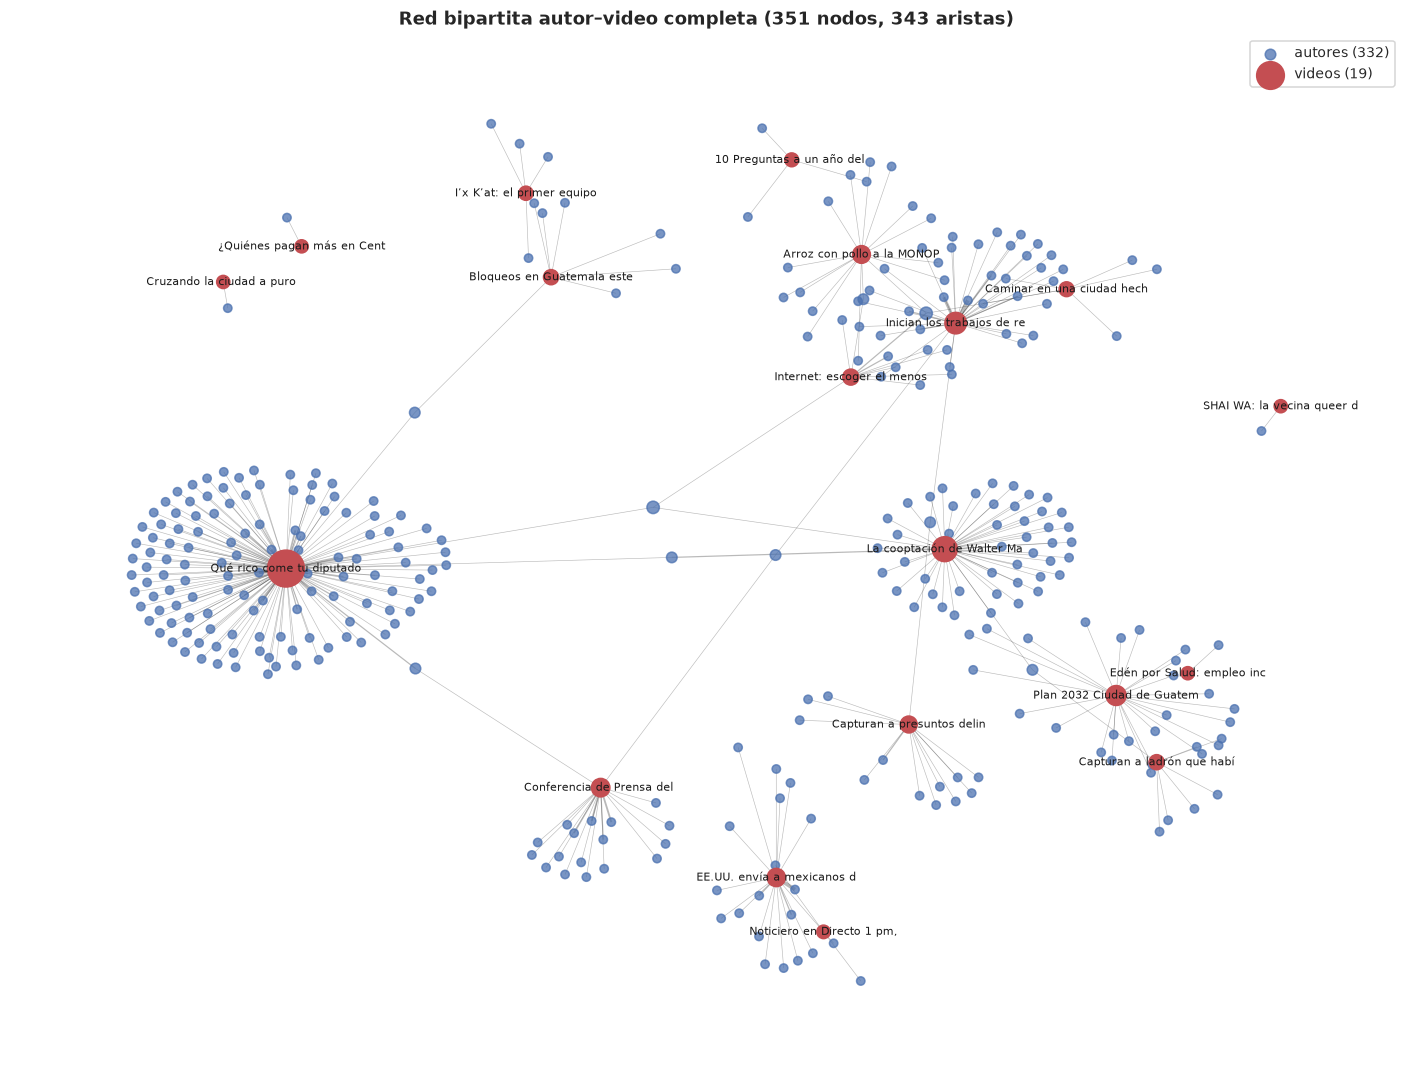

In [8]:
POS_SEMILLA = 42
tipo = nx.get_node_attributes(B, "tipo")
nodos_autor = [n for n in B if tipo[n] == "autor"]
nodos_video = [n for n in B if tipo[n] == "video"]
titulo_video = attr_videos.set_index("node_id")["etiqueta"].to_dict()

pos = nx.spring_layout(B, seed=POS_SEMILLA, k=0.30, iterations=120)

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_edges(B, pos, ax=ax, alpha=0.30, width=[0.4 * d["weight"] for *_, d in B.edges(data=True)])
nx.draw_networkx_nodes(B, pos, ax=ax, nodelist=nodos_autor, node_color="#4C72B0",
                       node_size=[12 + 18 * B.degree(n) for n in nodos_autor], alpha=0.75, label="autores (332)")
nx.draw_networkx_nodes(B, pos, ax=ax, nodelist=nodos_video, node_color="#C44E52",
                       node_size=[70 + 4 * B.degree(n) for n in nodos_video], label="videos (19)")
nx.draw_networkx_labels(B, pos, ax=ax,
                        labels={v: titulo_video[v][:26] for v in nodos_video}, font_size=7.5)
ax.set_title("Red bipartita autor–video completa (351 nodos, 343 aristas)")
ax.legend(loc="upper right", scatterpoints=1)
ax.axis("off")
plt.tight_layout()
plt.show()

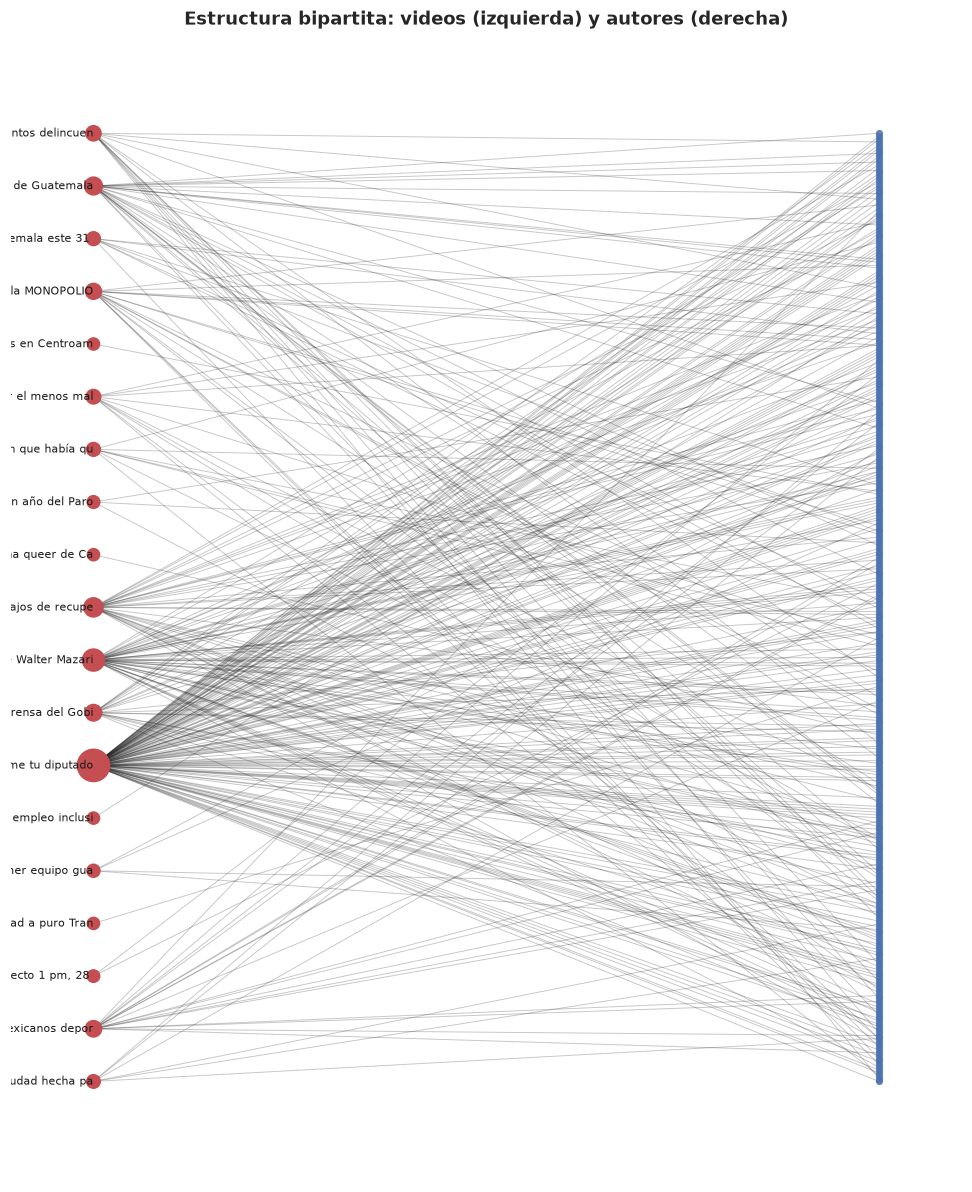

In [9]:
# Segunda vista: layout de dos columnas, que hace explícita la estructura bipartita
fig, ax = plt.subplots(figsize=(9, 11))
pos_bip = nx.bipartite_layout(B, nodos_video, align="vertical", aspect_ratio=2.5)

nx.draw_networkx_edges(B, pos_bip, ax=ax, alpha=0.25, width=0.6)
nx.draw_networkx_nodes(B, pos_bip, ax=ax, nodelist=nodos_autor, node_color="#4C72B0", node_size=14, alpha=0.8)
nx.draw_networkx_nodes(B, pos_bip, ax=ax, nodelist=nodos_video, node_color="#C44E52",
                       node_size=[60 + 3 * B.degree(n) for n in nodos_video])
nx.draw_networkx_labels(B, pos_bip, ax=ax,
                        labels={v: titulo_video[v][:30] for v in nodos_video}, font_size=7,
                        horizontalalignment="right")
ax.set_title("Estructura bipartita: videos (izquierda) y autores (derecha)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Ejercicio 5. Proyecciones de la red

Una **proyección** convierte la red de dos tipos de nodo en una de un solo tipo, conectando los nodos que compartían un vecino del otro tipo.

In [10]:
AA = nx.bipartite.weighted_projected_graph(B, autores)
VV = nx.bipartite.weighted_projected_graph(B, videos)

print("PROYECCIÓN AUTOR-AUTOR: dos autores se conectan si comentaron el mismo video")
print("  nodos:", AA.number_of_nodes(), "| aristas:", AA.number_of_edges())
pesos_aa = pd.Series([d["weight"] for *_, d in AA.edges(data=True)])
print("  peso = videos compartidos ->", pesos_aa.value_counts().sort_index().to_dict())
print()
print("PROYECCIÓN VIDEO-VIDEO: dos videos se conectan si comparten al menos un autor")
print("  nodos:", VV.number_of_nodes(), "| aristas:", VV.number_of_edges())
pesos_vv = pd.Series([d["weight"] for *_, d in VV.edges(data=True)])
print("  peso = autores compartidos ->", pesos_vv.value_counts().sort_index().to_dict())

PROYECCIÓN AUTOR-AUTOR: dos autores se conectan si comentaron el mismo video
  nodos: 332 | aristas: 10732
  peso = videos compartidos -> {1: 10730, 2: 2}

PROYECCIÓN VIDEO-VIDEO: dos videos se conectan si comparten al menos un autor
  nodos: 19 | aristas: 11
  peso = autores compartidos -> {1: 9, 2: 2}


In [ ]:
# ¿De dónde salen las 10,732 aristas autor-autor?
# Cada video con k autores genera un grupo completamente conectado de k(k-1)/2 aristas.
k_por_video = cv.groupby("video_id")["author_channel_id"].nunique().sort_values(ascending=False)
cliques = (k_por_video * (k_por_video - 1) // 2).rename("aristas_que_aporta")

resumen_clique = pd.DataFrame({
    "autores_del_video": k_por_video,
    "aristas_que_aporta": cliques,
    "% del total": (cliques / cliques.sum() * 100).round(1),
})
resumen_clique.index = resumen_clique.index.map(titulo_video)

print("Suma de todos los grupos completos:", int(cliques.sum()))
print("Aristas reales de la proyección:   ", AA.number_of_edges())
print("Diferencia:", int(cliques.sum()) - AA.number_of_edges(),
      "-> pares de autores contados dos veces, es decir, que comparten 2 videos")
resumen_clique.head(6)

Suma de todos los grupos completos: 10734
Aristas reales de la proyección:    10732
Diferencia: 2 -> pares de autores contados dos veces, es decir, que comparten 2 videos


,autores_del_video,aristas_que_aporta,% del total
video_id,,,
Qué rico come tu diputado,128,8128,75.7
La cooptación de Walter Mazariegos en la USAC,49,1176,11.0
Inician los trabajos de recuperación del Puente Belice II.,32,496,4.6
Plan 2032 Ciudad de Guatemala,25,300,2.8
Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,19,171,1.6
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,18,153,1.4


In [12]:
# Tabla completa de la proyección video-video
canal_video = attr_videos.set_index("node_id")["canal"].to_dict()
tabla_vv = pd.DataFrame([
    {"video_A": titulo_video[u][:34], "canal_A": canal_video[u],
     "video_B": titulo_video[v][:34], "canal_B": canal_video[v],
     "autores_compartidos": d["weight"], "mismo_canal": canal_video[u] == canal_video[v]}
    for u, v, d in VV.edges(data=True)
]).sort_values("autores_compartidos", ascending=False)

print("Aristas de la proyección video-video:", len(tabla_vv),
      "| entre videos del mismo canal:", int(tabla_vv["mismo_canal"].sum()))
print("Videos sin ninguna conexión (aislados):", len(list(nx.isolates(VV))))
tabla_vv

Aristas de la proyección video-video: 11 | entre videos del mismo canal: 7
Videos sin ninguna conexión (aislados): 9


,video_A,canal_A,video_B,canal_B,autores_compartidos,mismo_canal
10,Internet: escoger el menos malo,Quorum,Arroz con pollo a la MONOPOLIO,Quorum,2,True
7,La cooptación de Walter Mazariegos,Quorum,Qué rico come tu diputado,Quorum,2,True
0,Capturan a presuntos delincuentes,Noti7,Inician los trabajos de recuperaci,Gobierno de la República de Guatemala,1,False
2,Conferencia de Prensa del Gobierno,Gobierno de la República de Guatemala,Qué rico come tu diputado,Quorum,1,False
1,Inician los trabajos de recuperaci,Gobierno de la República de Guatemala,Conferencia de Prensa del Gobierno,Gobierno de la República de Guatemala,1,True
3,Caminar en una ciudad hecha para c,Quorum,Arroz con pollo a la MONOPOLIO,Quorum,1,True
4,Caminar en una ciudad hecha para c,Quorum,Internet: escoger el menos malo,Quorum,1,True
6,Capturan a ladrón que había quedad,TN23 Guatemala,La cooptación de Walter Mazariegos,Quorum,1,False
5,Bloqueos en Guatemala este 31 de a,PrensaLibreOficial,Qué rico come tu diputado,Quorum,1,False
8,La cooptación de Walter Mazariegos,Quorum,Internet: escoger el menos malo,Quorum,1,True


In [13]:
tabla_aa = pd.DataFrame(
    [{"autor_A": u, "autor_B": v, "videos_compartidos": d["weight"]} for u, v, d in AA.edges(data=True)]
)
tabla_aa.to_csv(DATA_PROCESSED / "aristas_autor_autor.csv", index=False)
tabla_vv.to_csv(DATA_PROCESSED / "aristas_video_video.csv", index=False)
print("guardado -> aristas_autor_autor.csv", tabla_aa.shape)
print("guardado -> aristas_video_video.csv", tabla_vv.shape)

guardado -> aristas_autor_autor.csv (10732, 3)
guardado -> aristas_video_video.csv (11, 6)


### 5.4 Visualización de las proyecciones

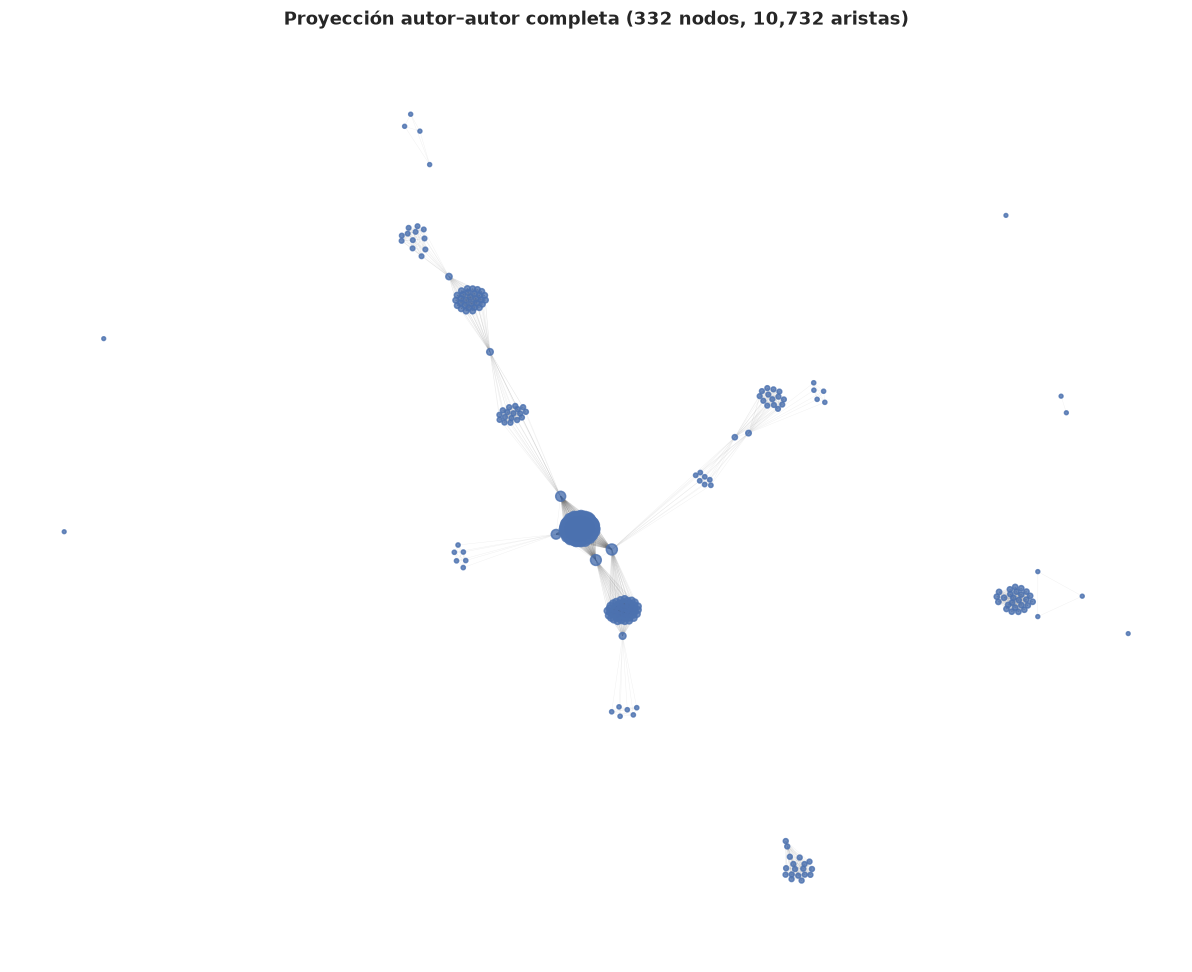

In [14]:
fig, ax = plt.subplots(figsize=(11, 9))
pos_aa = nx.spring_layout(AA, seed=POS_SEMILLA, k=0.12, iterations=60)
nx.draw_networkx_edges(AA, pos_aa, ax=ax, alpha=0.06, width=0.3)
nx.draw_networkx_nodes(AA, pos_aa, ax=ax, node_size=[6 + 0.25 * AA.degree(n) for n in AA],
                       node_color="#4C72B0", alpha=0.8)
ax.set_title("Proyección autor–autor completa (332 nodos, 10,732 aristas)")
ax.axis("off")
plt.tight_layout()
plt.show()

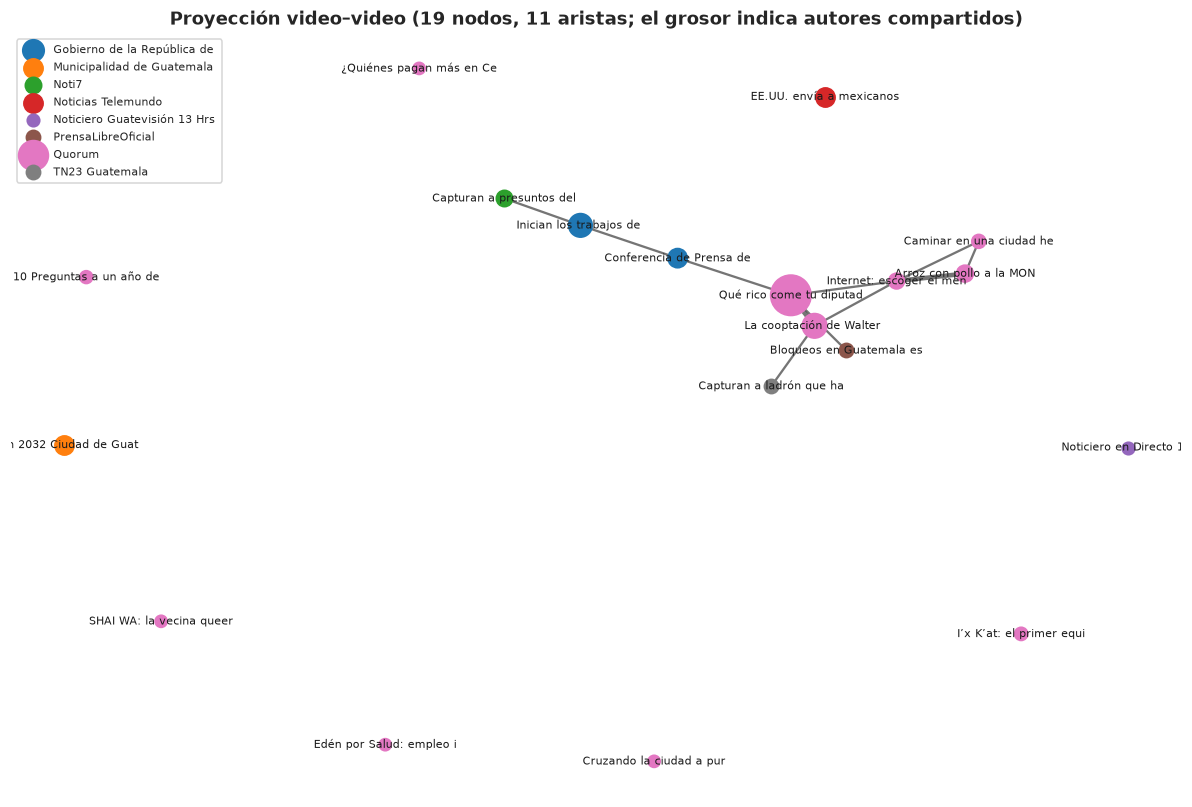

In [15]:
fig, ax = plt.subplots(figsize=(11, 7.5))
pos_vv = nx.spring_layout(VV, seed=POS_SEMILLA, k=1.1, iterations=200)
canales = sorted({canal_video[v] for v in VV})
colores = dict(zip(canales, plt.cm.tab10.colors))

nx.draw_networkx_edges(VV, pos_vv, ax=ax,
                       width=[1.5 * d["weight"] for *_, d in VV.edges(data=True)], alpha=0.6)
for c in canales:
    nodos_c = [v for v in VV if canal_video[v] == c]
    nx.draw_networkx_nodes(VV, pos_vv, ax=ax, nodelist=nodos_c, node_color=[colores[c]],
                           node_size=[60 + 4 * cv[cv["video_id"] == v].shape[0] for v in nodos_c],
                           label=c[:28])
nx.draw_networkx_labels(VV, pos_vv, ax=ax,
                        labels={v: titulo_video[v][:24] for v in VV}, font_size=7)
ax.set_title("Proyección video–video (19 nodos, 11 aristas; el grosor indica autores compartidos)")
ax.legend(loc="upper left", fontsize=7.5, scatterpoints=1)
ax.axis("off")
plt.tight_layout()
plt.show()

## Ejercicio 6. Topología y fragmentación

### 6.1 Métricas estructurales de las tres redes

In [16]:
def metricas(G, nombre, conjunto=None):
    """Resume la estructura de una red.

    En un grafo bipartito la densidad habitual subestima la conexión, porque cuenta
    como posibles las aristas autor-autor y video-video que están prohibidas por
    construcción. Por eso, cuando se pasa `conjunto`, se añade la densidad bipartita.
    """
    n, m = G.number_of_nodes(), G.number_of_edges()
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    gigante = G.subgraph(comps[0])
    fila = {
        "red": nombre,
        "nodos": n,
        "aristas": m,
        "densidad": round(nx.density(G), 5),
        "densidad_bipartita": round(nx.bipartite.density(G, conjunto), 5) if conjunto else np.nan,
        "grado_medio": round(2 * m / n, 3),
        "componentes": len(comps),
        "gigante_nodos": len(comps[0]),
        "gigante_%": round(len(comps[0]) / n * 100, 1),
        "aislados": len(list(nx.isolates(G))),
        "transitividad": round(nx.transitivity(G), 4),
        "clustering_medio": round(nx.average_clustering(G), 4),
    }
    if len(comps[0]) > 1:
        fila["diametro_gigante"] = nx.diameter(gigante)
        fila["camino_medio_gigante"] = round(nx.average_shortest_path_length(gigante), 3)
    return fila


topologia = pd.DataFrame([
    metricas(B, "bipartita autor–video", set(autores)),
    metricas(AA, "proyección autor–autor"),
    metricas(VV, "proyección video–video"),
])
topologia.to_csv(DATA_PROCESSED / "metricas_topologia.csv", index=False)
topologia.set_index("red").T

red,bipartita autor–video,proyección autor–autor,proyección video–video
nodos,351.00000,332.00000,19.00000
aristas,343.00000,10732.00000,11.00000
densidad,0.00558,0.19532,0.06433
densidad_bipartita,0.05438,NaN,NaN
grado_medio,1.95400,64.65100,1.15800
componentes,10.00000,10.00000,10.00000
gigante_nodos,286.00000,276.00000,10.00000
gigante_%,81.50000,83.10000,52.60000
aislados,0.00000,4.00000,9.00000
transitividad,0.00000,0.98400,0.31580


In [17]:
print("Tamaño de todas las componentes conexas")
for nombre, G in [("bipartita", B), ("autor–autor", AA), ("video–video", VV)]:
    tam = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
    print(f"  {nombre:14} -> {tam}")

Tamaño de todas las componentes conexas
  bipartita      -> [286, 26, 19, 5, 4, 3, 2, 2, 2, 2]
  autor–autor    -> [276, 25, 18, 4, 3, 2, 1, 1, 1, 1]
  video–video    -> [10, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### 6.2 Distribución de grados

In [18]:
grados_autor = np.array([B.degree(n) for n in nodos_autor])
grados_video = np.array([B.degree(n) for n in nodos_video])
grados_aa = np.array([d for _, d in AA.degree()])
grados_vv = np.array([d for _, d in VV.degree()])

print("BIPARTITA — grado de los autores (en cuántos videos comentó)")
print(f"  mediana {np.median(grados_autor):.0f} | media {grados_autor.mean():.2f} | máximo {grados_autor.max()}")
print(f"  con grado exactamente 1: {(grados_autor == 1).sum()} de {len(grados_autor)} "
      f"({(grados_autor == 1).mean():.1%})")
print("\nBIPARTITA — grado de los videos (cuántos autores distintos lo comentaron)")
print(f"  mediana {np.median(grados_video):.0f} | media {grados_video.mean():.2f} | máximo {grados_video.max()}")
print("\nPROYECCIÓN AUTOR-AUTOR")
print(f"  mediana {np.median(grados_aa):.0f} | media {grados_aa.mean():.2f} | máximo {grados_aa.max()}")
print("\nPROYECCIÓN VIDEO-VIDEO")
print(f"  mediana {np.median(grados_vv):.0f} | media {grados_vv.mean():.2f} | máximo {grados_vv.max()}")

BIPARTITA — grado de los autores (en cuántos videos comentó)
  mediana 1 | media 1.03 | máximo 3
  con grado exactamente 1: 323 de 332 (97.3%)

BIPARTITA — grado de los videos (cuántos autores distintos lo comentaron)
  mediana 7 | media 18.05 | máximo 128

PROYECCIÓN AUTOR-AUTOR
  mediana 48 | media 64.65 | máximo 183

PROYECCIÓN VIDEO-VIDEO
  mediana 1 | media 1.16 | máximo 4


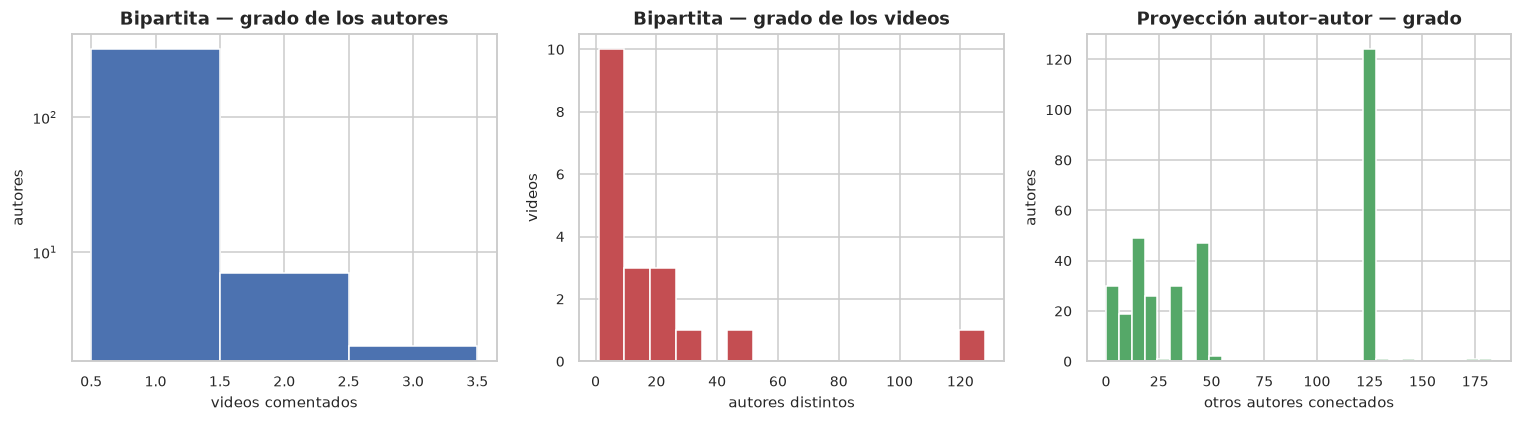

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(grados_autor, bins=np.arange(0.5, grados_autor.max() + 1.5), color="#4C72B0")
axes[0].set_title("Bipartita — grado de los autores")
axes[0].set_xlabel("videos comentados")
axes[0].set_ylabel("autores")
axes[0].set_yscale("log")

axes[1].hist(grados_video, bins=15, color="#C44E52")
axes[1].set_title("Bipartita — grado de los videos")
axes[1].set_xlabel("autores distintos")
axes[1].set_ylabel("videos")

axes[2].hist(grados_aa, bins=30, color="#55A868")
axes[2].set_title("Proyección autor–autor — grado")
axes[2].set_xlabel("otros autores conectados")
axes[2].set_ylabel("autores")
plt.tight_layout()
plt.show()

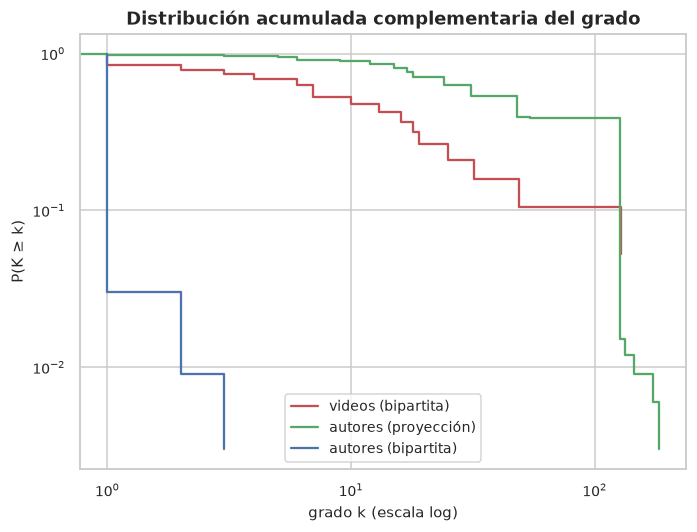

In [ ]:
# Complemento acumulado en log-log
fig, ax = plt.subplots(figsize=(6.5, 5))
for datos, etiqueta, color in [(grados_video, "videos (bipartita)", "#C44E52"),
                               (grados_aa, "autores (proyección)", "#55A868"),
                               (grados_autor, "autores (bipartita)", "#4C72B0")]:
    x = np.sort(datos)
    y = 1 - np.arange(len(x)) / len(x)
    ax.step(x, y, where="post", label=etiqueta, color=color)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Distribución acumulada complementaria del grado")
ax.set_xlabel("grado k (escala log)")
ax.set_ylabel("P(K ≥ k)")
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Cohesión, transitividad y fragilidad

La **cohesión** se mide aquí con la conectividad: cuántos nodos (o cuántas aristas) habría que quitar para partir en dos la componente más grande. Un valor de 1 significa que basta con quitar un solo elemento.

In [21]:
def cohesion(G, nombre):
    gigante = G.subgraph(max(nx.connected_components(G), key=len))
    return {
        "red": nombre,
        "nodos_gigante": gigante.number_of_nodes(),
        "aristas_gigante": gigante.number_of_edges(),
        "conectividad_nodos": nx.node_connectivity(gigante),
        "conectividad_aristas": nx.edge_connectivity(gigante),
        "puentes": len(list(nx.bridges(gigante))),
        "%_aristas_que_son_puente": round(len(list(nx.bridges(gigante))) / gigante.number_of_edges() * 100, 1),
        "puntos_articulacion": len(list(nx.articulation_points(gigante))),
        "transitividad": round(nx.transitivity(G), 4),
        "clustering_medio": round(nx.average_clustering(G), 4),
    }


pd.DataFrame([
    cohesion(B, "bipartita autor–video"),
    cohesion(AA, "proyección autor–autor"),
    cohesion(VV, "proyección video–video"),
]).set_index("red").T

red,bipartita autor–video,proyección autor–autor,proyección video–video
nodos_gigante,286.0,276.000,10.0000
aristas_gigante,287.0,10269.000,11.0000
conectividad_nodos,1.0,1.000,1.0000
conectividad_aristas,1.0,5.000,1.0000
puentes,279.0,0.000,5.0000
%_aristas_que_son_puente,97.2,0.000,45.5000
puntos_articulacion,17.0,7.000,5.0000
transitividad,0.0,0.984,0.3158
clustering_medio,0.0,0.972,0.1491


In [22]:
# Qué tipo de nodo son los puntos de articulación de la red bipartita
gigante_B = B.subgraph(max(nx.connected_components(B), key=len))
articulacion = list(nx.articulation_points(gigante_B))
serie = pd.Series([tipo[n] for n in articulacion]).value_counts()

print("Puntos de articulación en la componente gigante bipartita:", len(articulacion))
print(serie.to_string())
print("\nVideos que son punto de articulación (si se eliminan, la red se parte):")
for n in articulacion:
    if tipo[n] == "video":
        print(f"  {titulo_video[n][:52]:54} grado {B.degree(n):4} | canal {canal_video[n]}")

Puntos de articulación en la componente gigante bipartita: 17
video    10
autor     7

Videos que son punto de articulación (si se eliminan, la red se parte):
  Inician los trabajos de recuperación del Puente Beli   grado   32 | canal Gobierno de la República de Guatemala
  Capturan a presuntos delincuentes disfrazados de muj   grado   13 | canal Noti7
  Conferencia de Prensa del Gobierno de Guatemala. #La   grado   19 | canal Gobierno de la República de Guatemala
  Qué rico come tu diputado                              grado  128 | canal Quorum
  La cooptación de Walter Mazariegos en la USAC          grado   49 | canal Quorum
  Capturan a ladrón que había quedado grabado mientras   grado    7 | canal TN23 Guatemala
  Internet: escoger el menos malo                        grado   10 | canal Quorum
  Arroz con pollo a la MONOPOLIO                         grado   16 | canal Quorum
  Caminar en una ciudad hecha para carros                grado    6 | canal Quorum
  Bloqueos en Guatemala e

### 6.4 Nodos periféricos, aislados y ausencia de datos

In [ ]:
# Componentes pequeñas de la red bipartita (grupos periféricos)
comps_B = sorted(nx.connected_components(B), key=len, reverse=True)
periferia = []
for i, comp in enumerate(comps_B[1:], start=1):
    vids = [n for n in comp if tipo[n] == "video"]
    periferia.append({
        "componente": i,
        "nodos": len(comp),
        "autores": len(comp) - len(vids),
        "videos": len(vids),
        "titulos": " | ".join(titulo_video[v][:28] for v in vids),
        "canal": canal_video[vids[0]] if vids else "",
    })
print("Componentes periféricas de la red bipartita (todas menos la gigante):")
pd.DataFrame(periferia)

Componentes periféricas de la red bipartita (todas menos la gigante):


,componente,nodos,autores,videos,titulos,canal
0,1,26,25,1,Plan 2032 Ciudad de Guatemal,Municipalidad de Guatemala
1,2,19,18,1,EE.UU. envía a mexicanos dep,Noticias Telemundo
2,3,5,4,1,I’x K’at: el primer equipo g,Quorum
3,4,4,3,1,10 Preguntas a un año del Pa,Quorum
4,5,3,2,1,"Noticiero en Directo 1 pm, 2",Noticiero Guatevisión 13 Hrs.
5,6,2,1,1,¿Quiénes pagan más en Centro,Quorum
6,7,2,1,1,Cruzando la ciudad a puro Tr,Quorum
7,8,2,1,1,Edén por Salud: empleo inclu,Quorum
8,9,2,1,1,SHAI WA: la vecina queer de,Quorum


In [24]:
videos_totales = cargar("videos_limpio")
aislados_vv = [titulo_video[v] for v in nx.isolates(VV)]

print("TRES SITUACIONES QUE NO DEBEN CONFUNDIRSE")
print()
print("1. Nodos de grado 0 en la red bipartita:", len(list(nx.isolates(B))))
print("   Un nodo solo existe si participó, así que no puede haber aislados por construcción.")
print()
print("2. Videos aislados en la proyección video-video:", len(aislados_vv))
for t in aislados_vv:
    print("     -", t[:60])
print("   Aislamiento OBSERVADO: ninguno de sus comentaristas comentó en otro video de la muestra.")
print()
print("3. Videos del catálogo que NO están en la red:",
      int((~videos_totales['video_id'].isin(cv['video_id'])).sum()), "de", len(videos_totales))
print("   AUSENCIA DE DATOS: no se recolectaron sus comentarios. No son nodos aislados;")
print("   sencillamente no son nodos.")

TRES SITUACIONES QUE NO DEBEN CONFUNDIRSE

1. Nodos de grado 0 en la red bipartita: 0
   Un nodo solo existe si participó, así que no puede haber aislados por construcción.

2. Videos aislados en la proyección video-video: 9
     - Noticiero en Directo 1 pm, 28 de Agosto de 2026
     - 10 Preguntas a un año del Paro Nacional
     - EE.UU. envía a mexicanos deportados a Guatemala antes de su 
     - I’x K’at: el primer equipo guatemalteco de pelota maya, conf
     - SHAI WA: la vecina queer de Casa Presidencial
     - Cruzando la ciudad a puro Transmetro
     - Plan 2032 Ciudad de Guatemala
     - ¿Quiénes pagan más en Centroamérica?
     - Edén por Salud: empleo inclusivo para personas con discapaci
   Aislamiento OBSERVADO: ninguno de sus comentaristas comentó en otro video de la muestra.

3. Videos del catálogo que NO están en la red: 274 de 293
   AUSENCIA DE DATOS: no se recolectaron sus comentarios. No son nodos aislados;
   sencillamente no son nodos.


In [25]:
# Autores periféricos: los que solo conectan con un video y no aportan ningún puente
grado_uno = [n for n in nodos_autor if B.degree(n) == 1]
print(f"Autores con grado 1 (participaron en un único video): {len(grado_uno)} "
      f"({len(grado_uno)/len(nodos_autor):.1%} de los autores)")
print("Autores con grado ≥ 2 (los únicos que pueden conectar contenidos):",
      len(nodos_autor) - len(grado_uno))
print()
puente = nodos[(nodos["tipo"] == "autor") & (nodos["grado"] > 1)].sort_values(
    ["grado", "n_canales"], ascending=False)
puente[["node_id", "etiqueta", "grado", "n_comentarios", "n_videos", "n_canales"]]

Autores con grado 1 (participaron en un único video): 323 (97.3% de los autores)
Autores con grado ≥ 2 (los únicos que pueden conectar contenidos): 9



,node_id,etiqueta,grado,n_comentarios,n_videos,n_canales
276,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3,3,1
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,3,4,3,1
98,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,2,3,2,2
211,UCdFlugHJJa4l3YqWuNRmvXw,@marcoscarillo-b1r,2,2,2,2
250,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,2,2
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,2,2
207,UCbrtvygfRT6QXqWDNrOf-cA,@alejandro00710,2,2,2,1
325,UCylqlpsh8ENNM1LqgQ1KbxA,@jel.awesh.m,2,3,2,1
330,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2,2,1


## Ejercicio 7. Comunidades

Una **comunidad** es un grupo de nodos con muchas conexiones entre sí y pocas hacia afuera. Detectarlas es agrupar, pero usando la estructura de la red en vez de los atributos de los nodos.

### 7.1 Elección de la red

Dada la evidencia anterior, se aplica el mismo algoritmo a las tres redes disponibles y se compara la calidad de la partición resultante.

In [26]:
def probar_louvain(G, nombre, weight="weight", seed=42):
    com = nx.community.louvain_communities(G, weight=weight, resolution=1.0, seed=seed)
    return {
        "red": nombre,
        "comunidades": len(com),
        "modularidad_Q": round(nx.community.modularity(G, com, weight=weight), 4),
        "tamaño_mayor": max(len(c) for c in com),
        "comunidades_de_1_nodo": sum(1 for c in com if len(c) == 1),
    }


comps_como_particion = sorted(nx.connected_components(B), key=len, reverse=True)
comparacion_redes = pd.DataFrame([
    probar_louvain(B, "bipartita autor–video (ponderada)"),
    probar_louvain(B, "bipartita autor–video (sin pesos)", weight=None),
    probar_louvain(AA, "proyección autor–autor"),
    probar_louvain(VV, "proyección video–video"),
    {"red": "bipartita: partición por componentes", "comunidades": len(comps_como_particion),
     "modularidad_Q": round(nx.community.modularity(B, comps_como_particion, weight="weight"), 4),
     "tamaño_mayor": len(comps_como_particion[0]), "comunidades_de_1_nodo": 0},
])
comparacion_redes

,red,comunidades,modularidad_Q,tamaño_mayor,comunidades_de_1_nodo
0,bipartita autor–video (ponderada),17,0.7774,126,0
1,bipartita autor–video (sin pesos),17,0.7901,125,0
2,proyección autor–autor,14,0.3949,126,4
3,proyección video–video,12,0.4053,4,9
4,bipartita: partición por componentes,10,0.2785,286,0


**La red bipartita es la adecuada.**

- La **proyección autor–autor** obtiene Q = 0.395. Sus comunidades reproducen los grupos completos que la propia proyección creó, como se demostró en el Ejercicio 5. Buscar comunidades ahí equivale a redescubrir los videos por un camino más largo.
- La **proyección video–video** obtiene Q = 0.405, pero 9 de sus 12 comunidades son de un solo nodo. Con 19 nodos y 11 aristas no hay estructura suficiente que particionar.
- La **red bipartita ponderada** alcanza **Q = 0.777**, muy por encima de todas las alternativas y del rango 0.3–0.7 que suele considerarse útil.

Además de dar la mejor partición, la bipartita es la única que **conserva la información original sin inflarla**, y agrupa a los autores junto con el contenido que los reunió, que es la única relación que los datos registran.

Como referencia se incluye la partición por **componentes conexas**, que obtiene Q = 0.279: Louvain encuentra estructura muy por encima de la simple fragmentación de la red.

### 7.2 Algoritmo, supuestos y tratamiento de los pesos

Se aplica **Louvain**, que optimiza la modularidad de forma jerárquica; mueve nodos entre comunidades mientras la modularidad suba, y luego repite el proceso agrupando las comunidades halladas. Es el algoritmo más usado en la práctica por su rapidez.

Antes de aceptar el resultado se comprueban sus tres supuestos.

In [27]:
# Supuesto 1: estabilidad. Louvain es estocástico, así que se ejecuta con 20 semillas distintas.
resultados = [
    (len(c), round(nx.community.modularity(B, c, weight="weight"), 4))
    for c in (nx.community.louvain_communities(B, weight="weight", seed=s) for s in range(20))
]
n_com = pd.Series([r[0] for r in resultados])
q_val = pd.Series([r[1] for r in resultados])

print("SUPUESTO 1 — Estabilidad (20 semillas)")
print("  número de comunidades obtenido:", n_com.value_counts().sort_index().to_dict())
print(f"  modularidad -> mínimo {q_val.min()} | máximo {q_val.max()} | desviación {q_val.std():.5f}")

SUPUESTO 1 — Estabilidad (20 semillas)
  número de comunidades obtenido: {17: 20}
  modularidad -> mínimo 0.7774 | máximo 0.7774 | desviación 0.00000


**Supuesto 1: el resultado es estocástico.**

Louvain recorre los nodos en orden aleatorio, así que distintas ejecuciones pueden dar particiones distintas. En esta red **no ocurre**, las 20 semillas produjeron siempre 17 comunidades con Q = 0.7774 y desviación estándar 0.00000.

La partición es única y estable, así que no hace falta promediar corridas ni elegir la mejor.

In [28]:
# Supuesto 2: el modelo nulo. La modularidad de Newman compara contra una red aleatoria que
# permite aristas autor-autor, imposibles aquí. Barber (2007) propuso una versión bipartita
# cuyo modelo nulo solo admite aristas entre los dos conjuntos.
comunidades = nx.community.louvain_communities(B, weight="weight", seed=42)
pertenencia = {n: i for i, c in enumerate(comunidades) for n in c}

m_total = B.size(weight="weight")
grado_pond = dict(B.degree(weight="weight"))

Q_barber = sum(
    (B[a][v]["weight"] if B.has_edge(a, v) else 0) - grado_pond[a] * grado_pond[v] / m_total
    for a in autores for v in videos if pertenencia[a] == pertenencia[v]
) / m_total
Q_newman = nx.community.modularity(B, comunidades, weight="weight")

print("SUPUESTO 2 — Modelo nulo")
print(f"  Q de Newman (estándar):   {Q_newman:.5f}")
print(f"  Q de Barber (bipartita):  {Q_barber:.5f}")
print(f"  diferencia:               {Q_barber - Q_newman:.5f}")

SUPUESTO 2 — Modelo nulo
  Q de Newman (estándar):   0.77742
  Q de Barber (bipartita):  0.77744
  diferencia:               0.00002


**Supuesto 2: el modelo nulo.**

La modularidad compara las aristas dentro de los grupos contra las que habría en una red aleatoria con los mismos grados. El problema es que la versión estándar (la de Newman, que es la que optimiza Louvain) permite que esa red aleatoria tenga **aristas autor–autor**, imposibles en un grafo bipartito. El modelo nulo es, estrictamente, incorrecto.

Barber (2007) propuso una modularidad bipartita cuyo modelo nulo solo admite aristas entre los dos conjuntos. Aquí se calcula y da **0.77744** frente a **0.77742** de Newman, una diferencia de 0.00002, despreciable.

Esto **valida el uso de Louvain estándar en esta red**.

In [29]:
# Supuesto 3: tratamiento de los pesos.
com_pond = nx.community.louvain_communities(B, weight="weight", seed=42)
com_sin = nx.community.louvain_communities(B, weight=None, seed=42)
pert_sin = {n: i for i, c in enumerate(com_sin) for n in c}

coinciden = sum(
    1 for u in B for v in B
    if u < v and (pertenencia[u] == pertenencia[v]) == (pert_sin[u] == pert_sin[v])
)
pares = B.number_of_nodes() * (B.number_of_nodes() - 1) // 2

print("SUPUESTO 3 — Pesos")
print(f"  con pesos:  {len(com_pond)} comunidades")
print(f"  sin pesos:  {len(com_sin)} comunidades")
print(f"  pares de nodos clasificados igual por ambas variantes: {coinciden}/{pares} "
      f"({coinciden/pares:.2%})")

SUPUESTO 3 — Pesos
  con pesos:  17 comunidades
  sin pesos:  17 comunidades
  pares de nodos clasificados igual por ambas variantes: 61281/61425 (99.77%)


**Supuesto 3: el tratamiento de los pesos.**

Se ejecutan las dos variantes. Ambas dan 17 comunidades y clasifican igual al **99.77%** de los pares de nodos.

Se elige la **variante ponderada** porque el peso significa algo real (cuántos comentarios publicó ese autor en ese video) y descartarlo sería tirar información sin motivo. La versión sin pesos obtiene un Q ligeramente mayor (0.790), pero eso no la hace mejor.

**Sobre el límite de resolución:** la modularidad no detecta comunidades pequeñas dentro de redes grandes, y encuentra particiones con valores decentes incluso en grafos aleatorios. Por eso el Q = 0.777 no se interpreta solo, se contrasta contra las particiones alternativas de la sección 7.1, y las comunidades se revisan una por una en la sección siguiente.

**Nota:** Leiden corrige un defecto de Louvain (puede producir comunidades internamente mal conectadas) y se recomienda cuando la partición se va a interpretar. No se aplica aquí porque el defecto que corrige no se manifiesta en esta red (las 17 comunidades son estrellas conectadas por construcción y el resultado es estable).

### 7.3 Número de comunidades, tamaños y calidad

In [30]:
resumen_com = []
for i, c in enumerate(sorted(comunidades, key=len, reverse=True)):
    vids = [n for n in c if tipo[n] == "video"]
    auts = [n for n in c if tipo[n] == "autor"]
    resumen_com.append({
        "comunidad": i,
        "nodos": len(c),
        "autores": len(auts),
        "videos": len(vids),
        "comentarios": int(sum(B[a][v]["weight"] for a in auts for v in vids if B.has_edge(a, v))),
        "canales": ", ".join(sorted({canal_video[v] for v in vids}))[:44],
        "titulos": " | ".join(titulo_video[v][:26] for v in vids)[:70],
    })

resumen_com = pd.DataFrame(resumen_com)
print(f"Comunidades detectadas: {len(comunidades)} | modularidad Q = {Q_newman:.4f}")
print("Comunidades formadas por un solo tipo de nodo:",
      sum(1 for c in comunidades if len({tipo[n] for n in c}) == 1))
resumen_com

Comunidades detectadas: 17 | modularidad Q = 0.7774
Comunidades formadas por un solo tipo de nodo: 0


,comunidad,nodos,autores,videos,comentarios,canales,titulos
0,0,126,125,1,158,Quorum,Qué rico come tu diputado
1,1,48,47,1,48,Quorum,La cooptación de Walter Ma
2,2,32,29,3,34,Quorum,Caminar en una ciudad hech | Internet: escoger...
3,3,31,30,1,43,Gobierno de la República de Guatemala,Inician los trabajos de re
4,4,26,25,1,25,Municipalidad de Guatemala,Plan 2032 Ciudad de Guatem
5,5,19,18,1,25,Noticias Telemundo,EE.UU. envía a mexicanos d
6,6,19,18,1,24,Gobierno de la República de Guatemala,Conferencia de Prensa del
7,7,14,13,1,14,Noti7,Capturan a presuntos delin
8,8,8,7,1,7,PrensaLibreOficial,Bloqueos en Guatemala este
9,9,8,7,1,7,TN23 Guatemala,Capturan a ladrón que habí


**Las comunidades detectadas son públicos de video, no grupos sociales.**

Se hallaron **17 comunidades** con Q = 0.777, todas ellas mezclando autores y videos (ninguna quedó formada por un solo tipo de nodo). Los tamaños van de 126 a 2 nodos.

**16 de las 17 comunidades contienen exactamente un video** con su audiencia. Que un algoritmo que solo mira la estructura recupere casi exactamente la partición "un video y quienes lo comentaron" confirma que los autores no se agrupan entre sí, se agrupan alrededor del contenido.

La única excepción es la **comunidad 2**, que reúne **tres videos de Quorum** (*Internet: escoger el menos malo*, *Arroz con pollo a la MONOPOLIO* y *Caminar en una ciudad hecha para carros*) unidos por los autores que comentaron en más de uno. Es la única evidencia en todo el conjunto de algo parecido a una **audiencia de canal** en lugar de una audiencia de video.

Lo que esto **no** significa: pertenecer a la misma comunidad no implica que esas personas se conozcan, se lean o piensen igual. Significa únicamente que coincidieron en la sección de comentarios del mismo video.

In [31]:
# Cada comunidad se guarda como atributo del nodo y se exporta para el Notebook 4
orden = {c_id: i for i, c in enumerate(sorted(comunidades, key=len, reverse=True)) for c_id in c}
comunidades_nodos = nodos.copy()
comunidades_nodos["comunidad"] = comunidades_nodos["node_id"].map(orden)
comunidades_nodos.to_csv(DATA_PROCESSED / "comunidades_nodos.csv", index=False)
print("guardado -> comunidades_nodos.csv", comunidades_nodos.shape)
print(comunidades_nodos.groupby("comunidad")["tipo"].nunique().rename("tipos_por_comunidad").min(),
      "= mínimo de tipos por comunidad (2 significa que todas mezclan autores y videos)")

guardado -> comunidades_nodos.csv (351, 16)
2 = mínimo de tipos por comunidad (2 significa que todas mezclan autores y videos)


### 7.4 Visualización de todas las comunidades

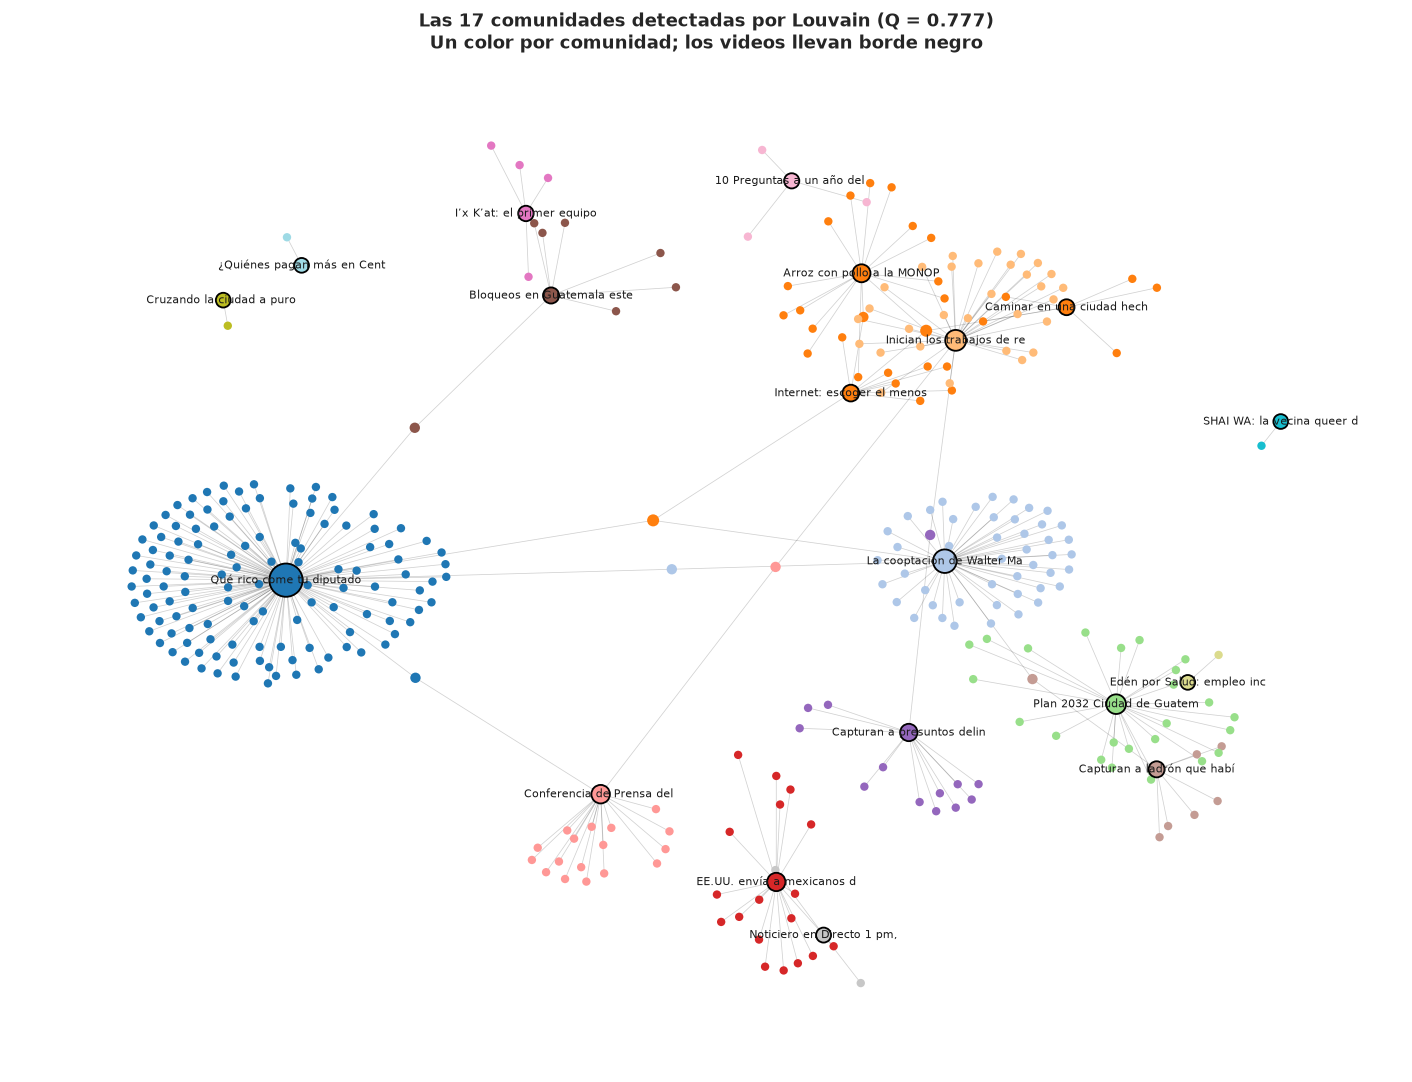

In [32]:
paleta = plt.cm.tab20(np.linspace(0, 1, len(comunidades)))
color_nodo = [paleta[orden[n]] for n in B]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_edges(B, pos, ax=ax, alpha=0.20, width=0.5)
nx.draw_networkx_nodes(B, pos, ax=ax, node_color=color_nodo,
                       node_size=[14 + 16 * B.degree(n) if tipo[n] == "autor" else 90 + 3 * B.degree(n)
                                  for n in B],
                       linewidths=[0 if tipo[n] == "autor" else 1.2 for n in B],
                       edgecolors="black")
nx.draw_networkx_labels(B, pos, ax=ax,
                        labels={v: titulo_video[v][:26] for v in nodos_video}, font_size=7.5)
ax.set_title(f"Las {len(comunidades)} comunidades detectadas por Louvain (Q = {Q_newman:.3f})\n"
             "Un color por comunidad; los videos llevan borde negro")
ax.axis("off")
plt.tight_layout()
plt.show()

La imagen hace visible el resultado de que cada estrella queda pintada de un color distinto. Se aprecia también que la comunidad 2 abarca tres centros en lugar de uno, y que los autores puente son los únicos puntos donde dos colores se tocan.

**Nota**: La posición de los nodos depende del layout, que es estocástico. Aquí se reutiliza la misma semilla que en la figura de la sección 4.4 para que ambas imágenes sean directamente comparables.

### 7.5 Caracterización de las tres comunidades principales

In [33]:
from collections import Counter

# Un comentario se atribuye a una comunidad cuando su autor Y su video pertenecen a ella.
# Los 9 autores puente comentan en videos de otra comunidad, y esos comentarios se excluyen
# para que los conteos coincidan con la tabla de la sección 7.3.
cv_com = cv.copy()
cv_com["com_autor"] = cv_com["author_channel_id"].map(orden)
cv_com["com_video"] = cv_com["video_id"].map(orden)
cruzados = int((cv_com["com_autor"] != cv_com["com_video"]).sum())
print(f"Comentarios cuyo autor y video están en comunidades distintas: {cruzados} de {len(cv_com)}\n")

for i in range(3):
    sub = cv_com[(cv_com["com_autor"] == i) & (cv_com["com_video"] == i)]
    fila = resumen_com.loc[i]
    tokens = Counter(t for lista in sub["tokens_comentario"] for t in lista)
    bigr = Counter(
        (t[j], t[j + 1]) for lista in sub["tokens_comentario"]
        for t in [list(lista)] for j in range(len(t) - 1)
    )
    print(f"COMUNIDAD {i} — {fila['nodos']} nodos ({fila['autores']} autores, {fila['videos']} videos)")
    print(f"   canal(es):     {fila['canales']}")
    print(f"   video(s):      {fila['titulos']}")
    print(f"   participación: {len(sub)} comentarios | "
          f"{len(sub)/sub['author_channel_id'].nunique():.2f} por autor | "
          f"{int(sub['like_count'].sum())} me gusta | {int(sub['reply_count'].sum())} respuestas")
    print(f"   temas:         {', '.join(p for p, _ in tokens.most_common(10))}")
    print(f"   bigramas:      {', '.join(' '.join(b) for b, _ in bigr.most_common(5))}")
    print()

Comentarios cuyo autor y video están en comunidades distintas: 8 de 406

COMUNIDAD 0 — 126 nodos (125 autores, 1 videos)
   canal(es):     Quorum
   video(s):      Qué rico come tu diputado
   participación: 158 comentarios | 1.26 por autor | 357 me gusta | 3 respuestas
   temas:         pueblo, diputado, pagar, dinero, trabajo, sueldo, almuerzo, trabajar, corrupto, ganar
   bigramas:      morir hambre, pagar sueldo, nery roda, pueblo pagar, diputado alcanzar

COMUNIDAD 1 — 48 nodos (47 autores, 1 videos)
   canal(es):     Quorum
   video(s):      La cooptación de Walter Ma
   participación: 48 comentarios | 1.02 por autor | 89 me gusta | 0 respuestas
   temas:         usac, corrupto, estudiante, universidad, excelente, información, universitario, sacar, seguir, pueblo
   bigramas:      pacto corrupto, reunión virtual, san carlos, urgente fiscalizar, excelente vídeo

COMUNIDAD 2 — 32 nodos (29 autores, 3 videos)
   canal(es):     Quorum
   video(s):      Caminar en una ciudad hech | In

**Caracterización de las Tres Comunidades Principales**

| | Comunidad 0 | Comunidad 1 | Comunidad 2 |
| --- | --- | --- | --- |
| Nodos | 126 | 48 | 32 |
| Autores | 125 | 47 | 29 |
| Videos | 1 | 1 | **3** |
| Canal | Quorum | Quorum | Quorum |
| Comentarios | 158 | 48 | 34 |
| Comentarios por autor | 1.26 | 1.02 | 1.17 |
| "Me gusta" | 357 | 89 | 17 |
| Temas | *pueblo, diputado, pagar, dinero, sueldo, almuerzo* | *usac, corrupto, estudiante, universidad* | *empresa, internet, ley, servicio* |
| Bigramas | *morir hambre, pagar sueldo, pueblo pagar* | *pacto corrupto, san carlos, urgente fiscalizar* | *ley competencia, libre mercado* |

Las tres pertenecen al mismo canal y aun así tratan **temas bastante distintos**: el gasto de los diputados, la situación de la Universidad de San Carlos, y la regulación del mercado de internet. Es decir, la comunidad no la define el canal sino **el video concreto**.

La intensidad de participación es baja y muy parecida en las tres (entre 1.02 y 1.26 comentarios por autor), lo que vuelve a confirmar que se trata de mucha gente comentando una vez, no de pocas personas comentando mucho. Donde sí hay diferencia grande es en los "me gusta": 357 en la comunidad 0 frente a 17 en la 2.

Ocho de los 406 comentarios corresponden a autores puente que escribieron en un video de otra comunidad; se excluyen de estos conteos para que los números coincidan con la tabla de la sección 7.3.

> **Sentimiento.**
> 
> La caracterización por sentimiento de estas comunidades se desarrolla en el **Ejercicio 9** (Notebook 4). La asignación de comunidad de cada nodo queda guardada en `data/processed/comunidades_nodos.csv` para ese propósito.

## Ejercicio 8. Nodos centrales y participantes puente

### 8.1 Medidas de centralidad

No hay una sola forma de ser importante en una red, así que se calculan cinco medidas que responden a preguntas distintas. Donde existe una versión bipartita se usa esa, porque normaliza contra el tamaño del **otro** conjunto en lugar de contra el total de nodos.

| Medida | Qué responde |
| --- | --- |
| Grado | ¿Cuánta participación directa concentra? |
| Intermediación | ¿Controla el paso entre regiones de la red? |
| Cercanía | ¿Qué tan rápido alcanza al resto? |
| PageRank | ¿Tiene prestigio, considerando el de sus vecinos? |
| Vector propio | ¿Está conectado a nodos importantes? |

In [34]:
# Las medidas basadas en caminos solo se definen dentro de una componente conexa.
# Se calculan sobre la componente gigante y quedan como NaN fuera de ella: registrar 0
# haría parecer periféricos a nodos cuya medida sencillamente no existe.
autores_gigante = [n for n in gigante_B if tipo[n] == "autor"]

centralidades = pd.DataFrame({
    "grado_bip": nx.bipartite.degree_centrality(B, set(autores)),
    "interm_bip": nx.bipartite.betweenness_centrality(gigante_B, autores_gigante),
    "cercania_bip": nx.bipartite.closeness_centrality(gigante_B, autores_gigante),
    "pagerank": nx.pagerank(B, weight="weight"),
    "vector_propio": nx.eigenvector_centrality_numpy(gigante_B, weight="weight"),
})
centralidades.index.name = "node_id"
centralidades = centralidades.reset_index()
centralidades["tipo"] = centralidades["node_id"].map(tipo)
centralidades["grado"] = centralidades["node_id"].map(dict(B.degree()))
centralidades["etiqueta"] = centralidades["node_id"].map(
    nodos.set_index("node_id")["etiqueta"].to_dict())

centralidades.to_csv(DATA_PROCESSED / "centralidades.csv", index=False)
print("Nodos totales:", len(centralidades))
print("Con intermediación definida (componente gigante):", int(centralidades["interm_bip"].notna().sum()))
print("Con intermediación NO definida (fuera de la gigante):", int(centralidades["interm_bip"].isna().sum()))
print("guardado -> centralidades.csv")

Nodos totales: 351
Con intermediación definida (componente gigante): 286
Con intermediación NO definida (fuera de la gigante): 65
guardado -> centralidades.csv


**Sobre las medidas que no siempre están definidas:** la intermediación, la cercanía y el vector propio se basan en caminos entre nodos, y entre dos nodos de componentes distintas **no existe ningún camino**. Por eso se calculan sobre la componente gigante (286 nodos) y quedan como **NaN** en los 65 nodos restantes.

Registrarlos como 0 sería un error, un 0 significa "está en la red y no controla ningún paso", mientras que NaN significa "la medida no está definida para este nodo". Confundirlos haría parecer irrelevante, por ejemplo, al video *Plan 2032 Ciudad de Guatemala*, que tiene 25 comentaristas pero pertenece a una componente aparte.

In [ ]:
# Las medidas no coinciden entre sí.
# Se calculan por separado porque autores y videos viven en escalas distintas.
cols = ["grado", "interm_bip", "cercania_bip", "pagerank", "vector_propio"]
for t in ["video", "autor"]:
    sub = centralidades[(centralidades["tipo"] == t) & centralidades["interm_bip"].notna()]
    print(f"Correlación de Spearman entre medidas — {'VIDEOS' if t == 'video' else 'AUTORES'} (n = {len(sub)})")
    print(sub[cols].corr(method="spearman").round(3).to_string())
    if t == "autor":
        print(f"  ATENCIÓN: {int((sub['interm_bip'] == 0).sum())} de {len(sub)} autores tienen "
              "intermediación exactamente 0.")
        print("  Con tantos empates, los coeficientes de correlación pierden significado.")
    print()

Correlación de Spearman entre medidas — VIDEOS (n = 10)
               grado  interm_bip  cercania_bip  pagerank  vector_propio
grado          1.000       0.927         0.638     0.997          0.638
interm_bip     0.927       1.000         0.784     0.924          0.784
cercania_bip   0.638       0.784         1.000     0.624          1.000
pagerank       0.997       0.924         0.624     1.000          0.624
vector_propio  0.638       0.784         1.000     0.624          1.000

Correlación de Spearman entre medidas — AUTORES (n = 276)
               grado  interm_bip  cercania_bip  pagerank  vector_propio
grado          1.000       1.000         0.111     0.291          0.065
interm_bip     1.000       1.000         0.113     0.291          0.066
cercania_bip   0.111       0.113         1.000    -0.128          0.970
pagerank       0.291       0.291        -0.128     1.000          0.005
vector_propio  0.065       0.066         0.970     0.005          1.000
  ATENCIÓN: 267 de 27

**Las medidas no coinciden.**

Entre los **videos** (n = 10), grado y PageRank van prácticamente juntos (0.997) porque ambos premian recibir muchas conexiones. En cambio, grado e intermediación se separan (0.927), y cercanía y vector propio forman un par aparte (1.000) (las dos miden proximidad al núcleo de la red, que aquí es el video más comentad).

Entre los **autores**, el resultado que parece más llamativo (correlación de 1.000 entre grado e intermediación) **debe descartarse**: 267 de los 276 autores de la componente gigante tienen intermediación exactamente 0, y con tantos empates el coeficiente de rangos deja de significar algo.

### 8.2 Interpretación para los videos

In [36]:
vista_videos = centralidades[centralidades["tipo"] == "video"].copy()
vista_videos["etiqueta"] = vista_videos["etiqueta"].str.slice(0, 34)
vista_videos.sort_values("interm_bip", ascending=False)[
    ["etiqueta", "grado", "grado_bip", "interm_bip", "cercania_bip", "pagerank", "vector_propio"]
].round(4)

,etiqueta,grado,grado_bip,interm_bip,cercania_bip,pagerank,vector_propio
338,Qué rico come tu diputado,128,0.3855,0.8539,0.3858,0.1673,0.7070
339,Conferencia de Prensa del Gobierno,19,0.0572,0.3684,0.2732,0.0249,0.0066
340,La cooptación de Walter Mazariegos,49,0.1476,0.3434,0.2805,0.0632,0.0105
341,Inician los trabajos de recuperaci,32,0.0964,0.2832,0.2005,0.0426,0.0000
345,Internet: escoger el menos malo,10,0.0301,0.1937,0.2678,0.0133,0.0030
347,Arroz con pollo a la MONOPOLIO,16,0.0482,0.0961,0.1844,0.0204,0.0000
350,Capturan a presuntos delincuentes,13,0.0392,0.0826,0.1482,0.0175,0.0000
343,Capturan a ladrón que había quedad,7,0.0211,0.0417,0.1849,0.0099,0.0000
348,Bloqueos en Guatemala este 31 de a,7,0.0211,0.0417,0.2255,0.0096,0.0028
332,Caminar en una ciudad hecha para c,6,0.0181,0.0348,0.1822,0.0081,0.0000


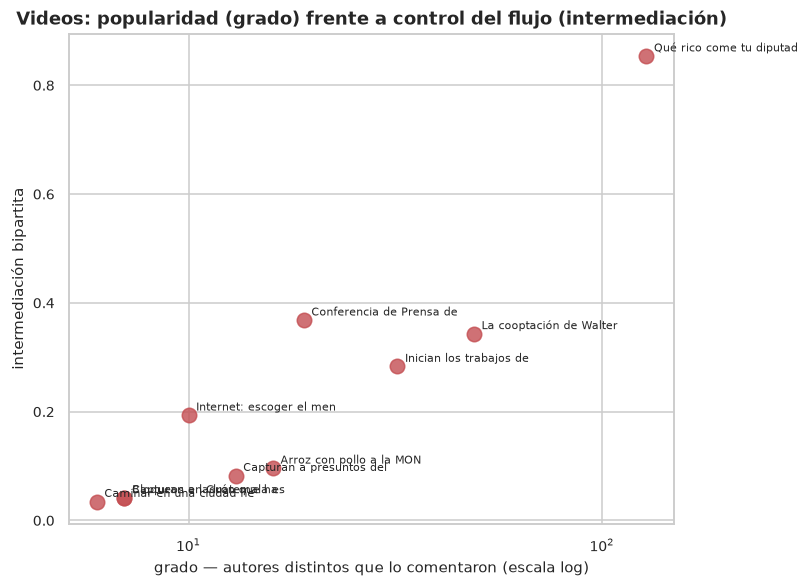

In [37]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
v = vista_videos.dropna(subset=["interm_bip"])
ax.scatter(v["grado"], v["interm_bip"], s=90, alpha=0.8, color="#C44E52")
for _, f in v.iterrows():
    ax.annotate(f["etiqueta"][:24], (f["grado"], f["interm_bip"]),
                fontsize=7, xytext=(5, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_title("Videos: popularidad (grado) frente a control del flujo (intermediación)")
ax.set_xlabel("grado — autores distintos que lo comentaron (escala log)")
ax.set_ylabel("intermediación bipartita")
plt.tight_layout()
plt.show()

**(Interpretación para los videos) Alcance frente a capacidad de conectar.**

*"Qué rico come tu diputado"* domina todas las medidas: el mayor grado (128 autores), la mayor intermediación (0.854), el mayor PageRank (0.167) y un vector propio de 0.707. Es a la vez el video más comentado y el que sostiene la red.

Pero el caso interesante es el segundo lugar. **"Conferencia de Prensa del Gobierno" tiene grado 19 e intermediación 0.368, por encima de "La cooptación de Walter Mazariegos", que tiene grado 49 e intermediación 0.343.** Un video con menos de la mitad de comentaristas resulta estructuralmente más importante, porque es el punto por donde la audiencia del Gobierno se conecta con la de Quorum.

El vector propio añade un matiz, cae a prácticamente cero en casi todos los videos salvo el principal. Esa medida premia estar conectado a nodos importantes, y en una red de estrellas los comentaristas de un video no aportan prestigio a ningún otro.

### 8.3 Interpretación para los autores: recurrencia y diversidad

In [38]:
perfil = centralidades[centralidades["tipo"] == "autor"].merge(
    nodos[["node_id", "n_comentarios", "n_videos", "n_canales", "grado_ponderado"]],
    on="node_id", how="left",
)

print("RECURRENTES — los 5 autores con más comentarios")
print(perfil.nlargest(5, "n_comentarios")[
    ["etiqueta", "n_comentarios", "n_videos", "n_canales", "interm_bip"]].round(4).to_string(index=False))
print()
print("PUENTE — los autores con intermediación mayor que cero")
print(perfil[perfil["interm_bip"] > 0].sort_values("interm_bip", ascending=False)[
    ["etiqueta", "n_comentarios", "n_videos", "n_canales", "interm_bip", "cercania_bip"]
].round(4).to_string(index=False))
print()
print("Autores con intermediación exactamente 0:",
      int((perfil["interm_bip"] == 0).sum()), "de", int(perfil["interm_bip"].notna().sum()),
      "en la componente gigante")

RECURRENTES — los 5 autores con más comentarios
              etiqueta  n_comentarios  n_videos  n_canales  interm_bip
    @murmullodelbarrio              6         1          1      0.0000
    @eugeneramirez4405              6         1          1         NaN
          @manueledran              5         1          1      0.0000
@albertoshernandez5251              5         1          1      0.0000
         @hashojea7348              4         3          1      0.0998

PUENTE — los autores con intermediación mayor que cero
            etiqueta  n_comentarios  n_videos  n_canales  interm_bip  cercania_bip
 @virgiliogarcia3039              3         2          2      0.3870        0.6100
      @inge_vergueta              3         3          1      0.3644        0.6407
        @josegil3813              2         2          1      0.2955        0.4409
        @jel.awesh.m              3         2          1      0.1490        0.5983
       @hashojea7348              4         3          

**(Interpretación para los autores) Recurrencia y diversidad son cosas distintas.**

La comparación de las dos tablas concluye:

1. Los **participantes recurrentes** (los que más comentan) concentran toda su actividad en un solo video. El más activo escribió 6 comentarios, todos en el mismo video, y su intermediación es **0**. Comentar mucho no conecta nada.
2. Los **autores puente** son los 9 con intermediación mayor que cero, y son gente que comentó poco (entre 2 y 4 comentarios). Lo que los hace estructuralmente importantes es la **diversidad**, no el volumen. `@virgiliogarcia3039` encabeza la lista con solo 3 comentarios, repartidos entre 2 videos de 2 canales distintos.

Los 267 autores restantes de la componente gigante tienen intermediación 0, al participar en un único video, no hay ningún camino que pase por ellos.

Este es un caso de **lazos débiles**; los vínculos que aportan conexión nueva no son los intensos, sino los que cruzan de un grupo a otro.

### Prueba de eliminación: ¿qué nodos parten la red?

Se elimina cada nodo y se mide en cuántas piezas queda la red y qué proporción conserva la mayor.

In [39]:
base = gigante_B.number_of_nodes()
prueba = []
for n in nx.articulation_points(gigante_B):
    H = gigante_B.copy()
    H.remove_node(n)
    piezas = sorted((len(c) for c in nx.connected_components(H)), reverse=True)
    prueba.append({
        "nodo": (titulo_video.get(n) or nodos.set_index("node_id")["etiqueta"][n])[:36],
        "tipo": tipo[n],
        "grado": B.degree(n),
        "piezas_resultantes": len(piezas),
        "mayor_pieza": piezas[0],
        "%_de_la_red_que_sobrevive_unida": round(piezas[0] / base * 100, 1),
    })

prueba = pd.DataFrame(prueba).sort_values("%_de_la_red_que_sobrevive_unida")
print(f"Componente gigante intacta: {base} nodos en 1 pieza")
prueba

Componente gigante intacta: 286 nodos en 1 pieza


,nodo,tipo,grado,piezas_resultantes,mayor_pieza,%_de_la_red_que_sobrevive_unida
4,Qué rico come tu diputado,video,128,127,88,30.8
15,@virgiliogarcia3039,autor,2,2,221,77.3
3,Conferencia de Prensa del Gobierno d,video,19,19,222,77.6
5,La cooptación de Walter Mazariegos e,video,49,48,231,80.8
16,@josegil3813,autor,2,2,240,83.9
0,Inician los trabajos de recuperación,video,32,32,241,84.3
12,@inge_vergueta,autor,3,2,254,88.8
8,Internet: escoger el menos malo,video,10,9,255,89.2
9,Arroz con pollo a la MONOPOLIO,video,16,15,271,94.8
2,@franciscoflores3120,autor,2,2,272,95.1


**La red se segmenta al quitar un solo nodo.**

Los resultados ordenan a los nodos por su importancia estructural.

- Eliminar **"Qué rico come tu diputado"** deja la red en **127 piezas**, y la mayor conserva solo 88 de los 286 nodos (**30.8%**). Un único video sostiene más de dos tercios de la componente principal.

- Los siguientes tres son `@virgiliogarcia3039` (queda el 77.3%), *"Conferencia de Prensa del Gobierno"* (77.6%) y *"La cooptación de Walter Mazariegos"* (80.8%).

La comparación entre esos dos primeros es el resultado más instructivo. Un autor con **2 comentarios** y un video con **19 comentaristas** tienen un efecto casi idéntico al ser eliminados. La importancia estructural no depende del volumen de participación, sino de la posición.

Hay que notar también la diferencia en la forma de romperse. Al quitar un video, la red estalla en decenas de piezas, porque cada uno de sus comentaristas queda suelto. Al quitar un autor puente, la red se parte limpiamente **en dos**, porque lo que se corta es el único enlace entre dos audiencias. Los videos concentran, los autores conectan.